In [1]:
import pandas as pd
import matplotlib.pyplot as plt

teku = pd.read_csv("../data/raw/teku.csv")
mid_b = pd.read_csv("../data/raw/mid_baneshwor.csv")

teku["datetime_utc"] = pd.to_datetime(teku["datetime_utc"])
mid_b["datetime_utc"] = pd.to_datetime(mid_b["datetime_utc"])

print("Teku:", teku.shape)
print("Mid Baneshwor:", mid_b.shape)

Teku: (4343, 6)
Mid Baneshwor: (3871, 6)


In [2]:
def reindex_hourly(df):
    full_range = pd.date_range(start=df["datetime_utc"].min(), end=df["datetime_utc"].max(), freq="h")
    return df.set_index("datetime_utc").reindex(full_range)

teku_r = reindex_hourly(teku)
mid_b_r = reindex_hourly(mid_b)

print("Teku reindexed:", teku_r.shape)
print("Mid Baneshwor reindexed:", mid_b_r.shape)

Teku reindexed: (6792, 5)
Mid Baneshwor reindexed: (6783, 5)


In [3]:
teku_r["was_missing"] = teku_r["pm25"].isna()
mid_b_r["was_missing"] = mid_b_r["pm25"].isna()

print("Teku missing hours:", teku_r['was_missing'].sum(), f"({teku_r['was_missing'].mean():.1%})")
print("Mid Baneshwor missing hours:", mid_b_r['was_missing'].sum(), f"({mid_b_r['was_missing'].mean():.1%})")

Teku missing hours: 2449 (36.1%)
Mid Baneshwor missing hours: 2912 (42.9%)


In [4]:
value_columns = ["pm1", "pm25", "relativehumidity", "temperature", "um003"]

def interpolate_short_gaps(df, columns, limit=3):
    df = df.copy()
    for col in columns:
        if col in df.columns:
            df[col] = df[col].interpolate(method="linear", limit=limit, limit_area="inside")
    return df

teku_clean = interpolate_short_gaps(teku_r, value_columns)
mid_b_clean = interpolate_short_gaps(mid_b_r, value_columns)

print("Teku pm25 still missing after interpolation:", teku_clean["pm25"].isna().sum())
print("Mid Baneshwor pm25 still missing after interpolation:", mid_b_clean["pm25"].isna().sum())

Teku pm25 still missing after interpolation: 2359
Mid Baneshwor pm25 still missing after interpolation: 2871


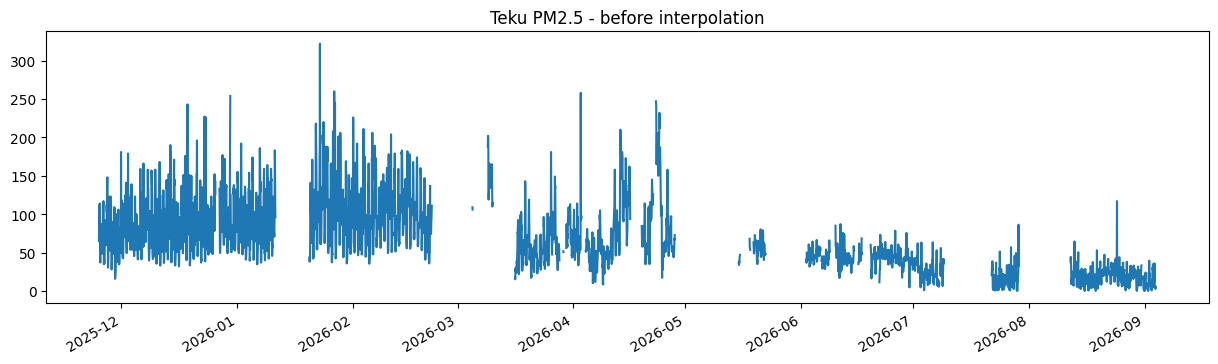

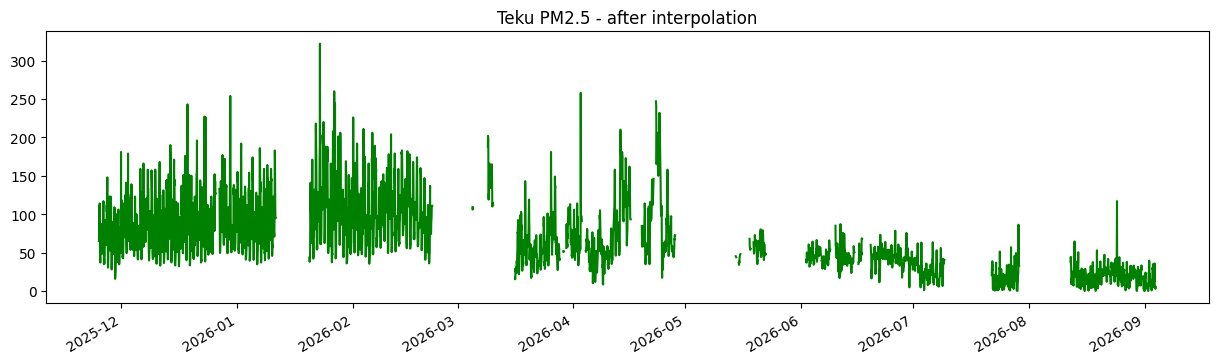

In [5]:
# Before interpolation
teku_r["pm25"].plot(
    figsize=(15, 4),
    title="Teku PM2.5 - before interpolation"
)
plt.show()

# After interpolation
teku_clean["pm25"].plot(
    figsize=(15, 4),
    title="Teku PM2.5 - after interpolation",
    color="green"
)
plt.show()

In [6]:
teku_clean = teku_clean.reset_index().rename(columns={"index": "datetime_utc"})
mid_b_clean = mid_b_clean.reset_index().rename(columns={"index": "datetime_utc"})

teku_clean["station"] = "teku"
mid_b_clean["station"] = "mid_baneshwor"

merged = pd.concat([teku_clean, mid_b_clean], ignore_index=True)
merged = merged.sort_values(["station", "datetime_utc"]).reset_index(drop=True)

print(merged.shape)
merged.head()

(13575, 8)


,datetime_utc,pm1,pm25,relativehumidity,temperature,um003,was_missing,station
0,2025-11-25 08:15:00+00:00,23.5,38.9,38.5,21.3,1370.0,False,mid_baneshwor
1,2025-11-25 09:15:00+00:00,27.5,44.9,38.1,21.9,1790.0,False,mid_baneshwor
2,2025-11-25 10:15:00+00:00,29.2,48.9,39.3,21.3,1980.0,False,mid_baneshwor
3,2025-11-25 11:15:00+00:00,29.0,48.0,41.2,20.2,1980.0,False,mid_baneshwor
4,2025-11-25 12:15:00+00:00,29.9,49.4,40.9,20.1,2060.0,False,mid_baneshwor


In [7]:
import os
os.makedirs("../data/processed", exist_ok=True)
merged.to_csv("../data/processed/kathmandu_merged.csv", index=False)
print(f"Saved {len(merged)} rows to ../data/processed/kathmandu_merged.csv")

Saved 13575 rows to ../data/processed/kathmandu_merged.csv


In [8]:
print(merged["station"].value_counts())
print()
print(merged.groupby("station")["was_missing"].mean())
print()
print(merged.isna().sum())

station
teku             6792
mid_baneshwor    6783
Name: count, dtype: int64

station
mid_baneshwor    0.429309
teku             0.360571
Name: was_missing, dtype: float64

datetime_utc           0
pm1                 5230
pm25                5230
relativehumidity    5230
temperature         5230
um003               5230
was_missing            0
station                0
dtype: int64
